## MLP Model

In [ ]:
# import packages and dataset
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

url = "https://raw.githubusercontent.com/lwenqing090-web/traffic-signal-ml-project/refs/heads/main/data/cleansed_traffic_monitoring.csv"
df = pd.read_csv(url)

In [ ]:
# use selected features
features = [
    'Traffic_Speed',
    'Road_Length',
    'Traffic_Volume',
    'Traffic_Density',
    'Signal_Phase_Duration',
    'Time_of_Day'
]

X = df[features]
y = df['Travel_Time']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# build MLP model
mlp = MLPRegressor(
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

# define hyperparameter space
param_dist = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [64, 128, 256]
}

# randomized search
random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=MLPRegressor(early_stopping=True, max_iter=300,
                                          random_state=42),
                   n_jobs=-1,
                   param_distributions={'activation': ['relu', 'tanh'],
                                        'alpha': [0.0001, 0.001, 0.01],
                                        'batch_size': [64, 128, 256],
                                        'hidden_layer_sizes': [(32,), (64,),
                                                               (64, 32),
                                                               (128, 64)],
                                        'learning_rate_init': [0.001, 0.01]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [ ]:
# find the best model
best_mlp = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score (negative MSE):")
print(random_search.best_score_)

# predict
y_pred_mlp = best_mlp.predict(X_test_scaled)

# evaluate model
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("\nTuned MLP Regressor Results")
print("Test MSE:", mse_mlp)
print("Test MAE:", mae_mlp)
print("Test R^2:", r2_mlp)

Best Parameters:
{'learning_rate_init': 0.01, 'hidden_layer_sizes': (32,), 'batch_size': 256, 'alpha': 0.01, 'activation': 'relu'}

Best CV Score (negative MSE):
-2.1631049798571227

Tuned MLP Regressor Results
Test MSE: 2.146296110036685
Test MAE: 1.2483647519783965
Test R^2: 0.9477953238920463


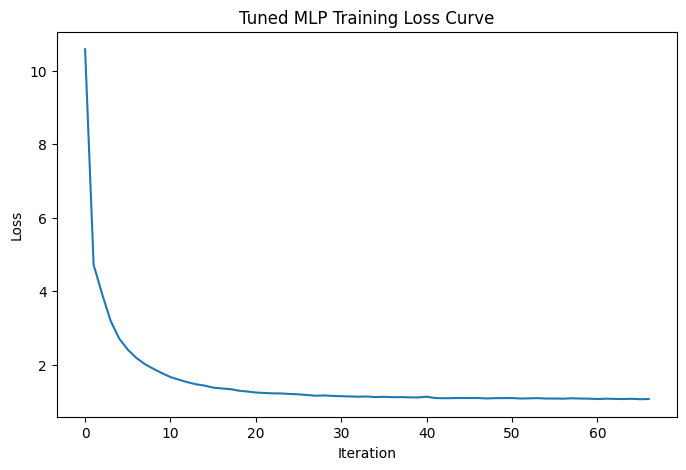

In [ ]:
# visualization
# plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Tuned MLP Training Loss Curve")
plt.show()

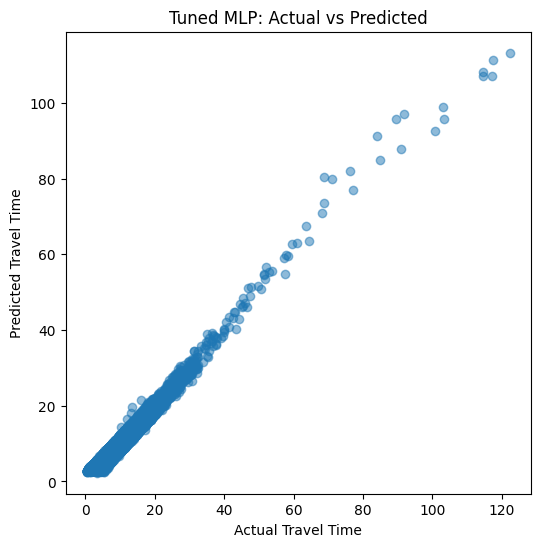

In [ ]:
# plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.5)
plt.xlabel("Actual Travel Time")
plt.ylabel("Predicted Travel Time")
plt.title("Tuned MLP: Actual vs Predicted")
plt.show()

## Optimization


PART A: Unconstrained Optimization
Optimization result for one traffic condition (unconstrained):
    Signal_Phase_Duration  Predicted_Travel_Time  Objective_Score
0                      30              12.130947        12.130947
1                      40              12.115268        12.115268
2                      50              12.099589        12.099589
3                      60              12.083910        12.083910
4                      70              12.068232        12.068232
5                      80              12.052553        12.052553
6                      90              12.036874        12.036874
7                     100              12.021195        12.021195
8                     110              12.005516        12.005516
9                     120              11.989837        11.989837
10                    130              11.974158        11.974158
11                    140              11.958480        11.958480
12                    150              11.9

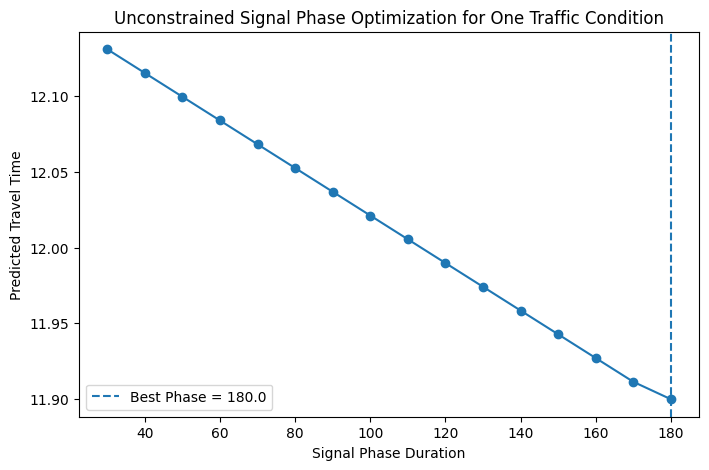


Unconstrained multi-sample summary:
   Best_Phase  Best_Predicted_Travel_Time
0       180.0                    6.988868
1       140.0                   11.084153
2       140.0                    6.572710
3       180.0                    8.565511
4       180.0                   17.363427

Average optimal phase (unconstrained): 174.4
Most common optimal phase (unconstrained): 180.0
Average minimum predicted travel time (unconstrained): 9.344837702224792


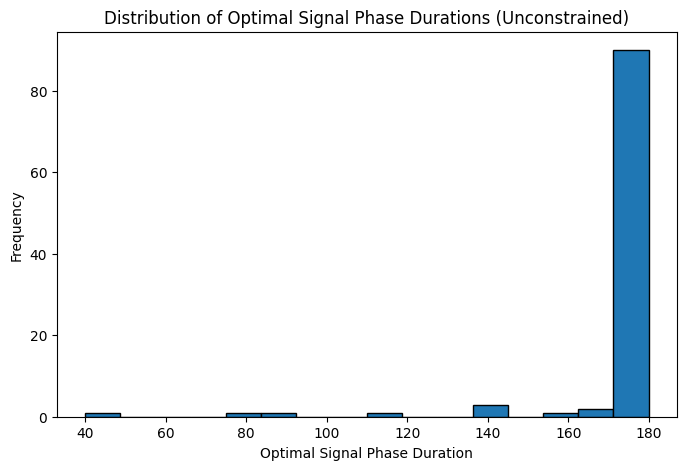

In [ ]:
# Signal Phase Optimization
def optimize_signal_phase_for_sample(
    sample,
    model,
    scaler,
    features,
    phase_candidates,
    penalty_lambda=0.0
):
    results = []

    for phase in phase_candidates:
        temp_sample = sample.copy()
        temp_sample['Signal_Phase_Duration'] = phase

        temp_df = pd.DataFrame([temp_sample], columns=features)
        temp_scaled = scaler.transform(temp_df)

        pred_time = model.predict(temp_scaled)[0]
        objective_score = pred_time + penalty_lambda * phase

        results.append({
            'Signal_Phase_Duration': phase,
            'Predicted_Travel_Time': pred_time,
            'Objective_Score': objective_score
        })

    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df['Objective_Score'].idxmin()]

    return results_df, best_row

# unconstrained optimization
print("\n" + "="*60)
print("PART A: Unconstrained Optimization")
print("="*60)

# choose one sample from the original dataframe
sample_idx = 0
sample = df.loc[sample_idx, features].copy()

# original phase search range
phase_candidates_full = np.arange(30, 181, 10)

# no penalty
penalty_lambda_unconstrained = 0.0

results_unconstrained_df, best_unconstrained_row = optimize_signal_phase_for_sample(
    sample=sample,
    model=best_mlp,
    scaler=scaler,
    features=features,
    phase_candidates=phase_candidates_full,
    penalty_lambda=penalty_lambda_unconstrained
)

print("Optimization result for one traffic condition (unconstrained):")
print(results_unconstrained_df)
print("\nBest signal phase duration (unconstrained):",
      best_unconstrained_row['Signal_Phase_Duration'])
print("Minimum predicted travel time (unconstrained):",
      best_unconstrained_row['Predicted_Travel_Time'])

# plot unconstrained result
plt.figure(figsize=(8, 5))
plt.plot(
    results_unconstrained_df['Signal_Phase_Duration'],
    results_unconstrained_df['Predicted_Travel_Time'],
    marker='o'
)
plt.axvline(
    best_unconstrained_row['Signal_Phase_Duration'],
    linestyle='--',
    label=f"Best Phase = {best_unconstrained_row['Signal_Phase_Duration']}"
)
plt.xlabel("Signal Phase Duration")
plt.ylabel("Predicted Travel Time")
plt.title("Unconstrained Signal Phase Optimization for One Traffic Condition")
plt.legend()
plt.show()

# multiple samples
n_samples = 100
test_subset = X_test.iloc[:n_samples].copy()

all_best_phases_unconstrained = []
all_best_times_unconstrained = []

for i in range(len(test_subset)):
    base_sample = test_subset.iloc[i].copy()

    sample_results_df, best_row = optimize_signal_phase_for_sample(
        sample=base_sample,
        model=best_mlp,
        scaler=scaler,
        features=features,
        phase_candidates=phase_candidates_full,
        penalty_lambda=penalty_lambda_unconstrained
    )

    all_best_phases_unconstrained.append(best_row['Signal_Phase_Duration'])
    all_best_times_unconstrained.append(best_row['Predicted_Travel_Time'])

summary_unconstrained_df = pd.DataFrame({
    'Best_Phase': all_best_phases_unconstrained,
    'Best_Predicted_Travel_Time': all_best_times_unconstrained
})

print("\nUnconstrained multi-sample summary:")
print(summary_unconstrained_df.head())
print("\nAverage optimal phase (unconstrained):", summary_unconstrained_df['Best_Phase'].mean())
print("Most common optimal phase (unconstrained):", summary_unconstrained_df['Best_Phase'].mode()[0])
print("Average minimum predicted travel time (unconstrained):",
      summary_unconstrained_df['Best_Predicted_Travel_Time'].mean())

plt.figure(figsize=(8, 5))
plt.hist(summary_unconstrained_df['Best_Phase'],
         bins=len(phase_candidates_full),
         edgecolor='black')
plt.xlabel("Optimal Signal Phase Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Optimal Signal Phase Durations (Unconstrained)")
plt.show()

In [ ]:
# improved optimization with realistic constraints
print("\n" + "="*60)
print("PART B: Improved Optimization with Constraints")
print("="*60)

# signal phase range
phase_candidates_practical = np.arange(30, 121, 10)

# penalty coefficient
penalty_lambda_constrained = 0.0005

results_constrained_df, best_constrained_row = optimize_signal_phase_for_sample(
    sample=sample,
    model=best_mlp,
    scaler=scaler,
    features=features,
    phase_candidates=phase_candidates_practical,
    penalty_lambda=penalty_lambda_constrained
)

print("Optimization result for one traffic condition (constrained):")
print(results_constrained_df)
print("\nBest signal phase duration (constrained):",
      best_constrained_row['Signal_Phase_Duration'])
print("Minimum predicted travel time (constrained):",
      best_constrained_row['Predicted_Travel_Time'])
print("Minimum objective score (constrained):",
      best_constrained_row['Objective_Score'])


PART B: Improved Optimization with Constraints
Optimization result for one traffic condition (constrained):
   Signal_Phase_Duration  Predicted_Travel_Time  Objective_Score
0                     30              12.130947        12.145947
1                     40              12.115268        12.135268
2                     50              12.099589        12.124589
3                     60              12.083910        12.113910
4                     70              12.068232        12.103232
5                     80              12.052553        12.092553
6                     90              12.036874        12.081874
7                    100              12.021195        12.071195
8                    110              12.005516        12.060516
9                    120              11.989837        12.049837

Best signal phase duration (constrained): 120.0
Minimum predicted travel time (constrained): 11.989837246368754
Minimum objective score (constrained): 12.049837246368755


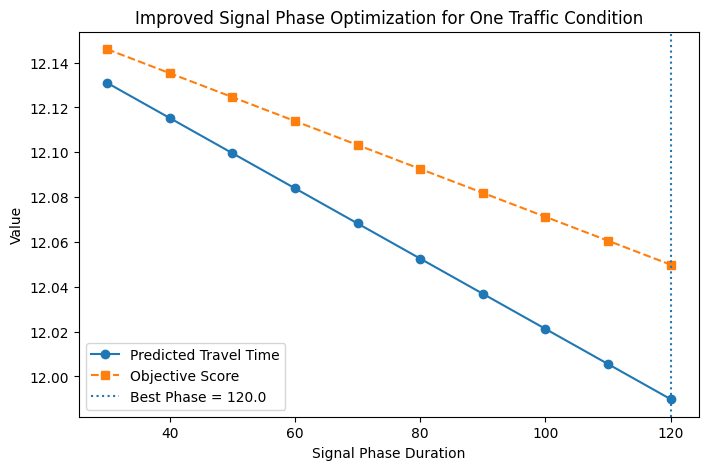


Constrained multi-sample summary:
   Best_Phase  Best_Predicted_Travel_Time  Best_Objective_Score
0       120.0                    7.042009              7.102009
1       120.0                   11.104037             11.164037
2       120.0                    6.584925              6.644925
3       120.0                    8.725557              8.785557
4       120.0                   17.542509             17.602509

Average optimal phase (constrained): 112.6
Most common optimal phase (constrained): 120.0
Average minimum predicted travel time (constrained): 9.435884741640443
Average minimum objective score (constrained): 9.492184741640441


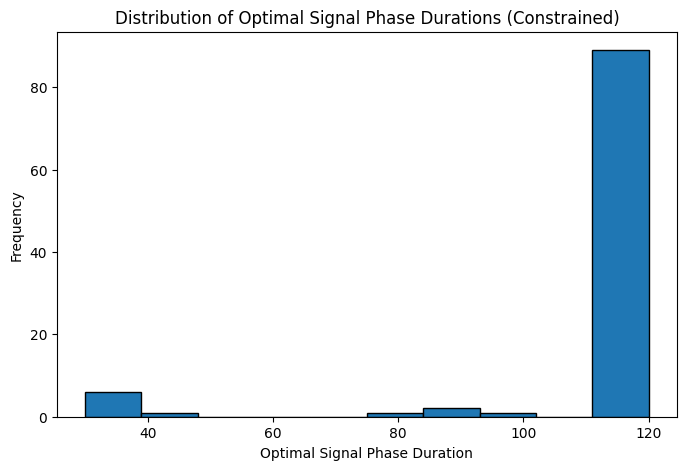

In [ ]:
# plot constrained result
plt.figure(figsize=(8, 5))
plt.plot(
    results_constrained_df['Signal_Phase_Duration'],
    results_constrained_df['Predicted_Travel_Time'],
    marker='o',
    label='Predicted Travel Time'
)
plt.plot(
    results_constrained_df['Signal_Phase_Duration'],
    results_constrained_df['Objective_Score'],
    marker='s',
    linestyle='--',
    label='Objective Score'
)
plt.axvline(
    best_constrained_row['Signal_Phase_Duration'],
    linestyle=':',
    label=f"Best Phase = {best_constrained_row['Signal_Phase_Duration']}"
)
plt.xlabel("Signal Phase Duration")
plt.ylabel("Value")
plt.title("Improved Signal Phase Optimization for One Traffic Condition")
plt.legend()
plt.show()

# multiple samples - constrained
all_best_phases_constrained = []
all_best_times_constrained = []
all_best_scores_constrained = []

for i in range(len(test_subset)):
    base_sample = test_subset.iloc[i].copy()

    sample_results_df, best_row = optimize_signal_phase_for_sample(
        sample=base_sample,
        model=best_mlp,
        scaler=scaler,
        features=features,
        phase_candidates=phase_candidates_practical,
        penalty_lambda=penalty_lambda_constrained
    )

    all_best_phases_constrained.append(best_row['Signal_Phase_Duration'])
    all_best_times_constrained.append(best_row['Predicted_Travel_Time'])
    all_best_scores_constrained.append(best_row['Objective_Score'])

summary_constrained_df = pd.DataFrame({
    'Best_Phase': all_best_phases_constrained,
    'Best_Predicted_Travel_Time': all_best_times_constrained,
    'Best_Objective_Score': all_best_scores_constrained
})

print("\nConstrained multi-sample summary:")
print(summary_constrained_df.head())

print("\nAverage optimal phase (constrained):", summary_constrained_df['Best_Phase'].mean())
print("Most common optimal phase (constrained):", summary_constrained_df['Best_Phase'].mode()[0])
print("Average minimum predicted travel time (constrained):",
      summary_constrained_df['Best_Predicted_Travel_Time'].mean())
print("Average minimum objective score (constrained):",
      summary_constrained_df['Best_Objective_Score'].mean())

plt.figure(figsize=(8, 5))
plt.hist(summary_constrained_df['Best_Phase'],
         bins=len(phase_candidates_practical),
         edgecolor='black')
plt.xlabel("Optimal Signal Phase Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Optimal Signal Phase Durations (Constrained)")
plt.show()

In [ ]:
# compare unconstrained vs constrained
print("\n" + "="*60)
print("PART C: Comparison")
print("="*60)

comparison_df = pd.DataFrame({
    'Setting': ['Unconstrained', 'Constrained'],
    'Average_Optimal_Phase': [
        summary_unconstrained_df['Best_Phase'].mean(),
        summary_constrained_df['Best_Phase'].mean()
    ],
    'Most_Common_Optimal_Phase': [
        summary_unconstrained_df['Best_Phase'].mode()[0],
        summary_constrained_df['Best_Phase'].mode()[0]
    ],
    'Average_Minimum_Predicted_Travel_Time': [
        summary_unconstrained_df['Best_Predicted_Travel_Time'].mean(),
        summary_constrained_df['Best_Predicted_Travel_Time'].mean()
    ]
})

print(comparison_df)


PART C: Comparison
         Setting  Average_Optimal_Phase  Most_Common_Optimal_Phase  \
0  Unconstrained                  174.4                      180.0   
1    Constrained                  112.6                      120.0   

   Average_Minimum_Predicted_Travel_Time  
0                               9.344838  
1                               9.435885  


In [ ]:
lambdas = [0.0, 0.0005, 0.001, 0.005, 0.01]
lambda_results = []

for lam in [0.0, 0.0005, 0.001, 0.005, 0.01]:
    _, best_row = optimize_signal_phase_for_sample(
        sample=sample,
        model=best_mlp,
        scaler=scaler,
        features=features,
        phase_candidates=phase_candidates_practical,
        penalty_lambda=lam
    )

    lambda_results.append({
        'lambda': lam,
        'best_phase': best_row['Signal_Phase_Duration'],
        'best_predicted_time': best_row['Predicted_Travel_Time'],
        'best_objective_score': best_row['Objective_Score']
    })

lambda_df = pd.DataFrame(lambda_results)
print(lambda_df)

   lambda  best_phase  best_predicted_time  best_objective_score
0  0.0000       120.0            11.989837             11.989837
1  0.0005       120.0            11.989837             12.049837
2  0.0010       120.0            11.989837             12.109837
3  0.0050        30.0            12.130947             12.280947
4  0.0100        30.0            12.130947             12.430947


## Time-based split: use the last year as test set

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# load dataset
url = "https://raw.githubusercontent.com/lwenqing090-web/traffic-signal-ml-project/main/data/cleansed_traffic_monitoring.csv"
df = pd.read_csv(url)

# convert timestamp to datetime and sort by time
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.sort_values("Timestamp").reset_index(drop=True)
df = df.dropna(subset=["Timestamp"])

# feature selection
features = [
    "Traffic_Speed",
    "Road_Length",
    "Traffic_Volume",
    "Traffic_Density",
    "Signal_Phase_Duration",
    "Time_of_Day"
]

target = "Travel_Time"

X = df[features]
y = df[target]

# time-based split
# use the last year as the test set
last_year = df["Timestamp"].dt.year.max()
train_df = df[df["Timestamp"].dt.year < last_year].copy()
test_df = df[df["Timestamp"].dt.year == last_year].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Last year used for test:", last_year)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MLP model
mlp = MLPRegressor(
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=SEED
)

# hyperparameter tuning
param_dist = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [64, 128, 256]
}

random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

# best model
best_mlp = random_search.best_estimator_
print("\nBest Parameters:")
print(random_search.best_params_)
print("\nBest CV Score (negative MSE):")
print(random_search.best_score_)

# prediction
y_pred_mlp = best_mlp.predict(X_test_scaled)

# evaluation
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("\nTuned MLP Regressor Results")
print("Test MSE:", mse_mlp)
print("Test MAE:", mae_mlp)
print("Test R^2:", r2_mlp)

results_df = pd.DataFrame({
    "Actual_Travel_Time": y_test.values,
    "Predicted_Travel_Time": y_pred_mlp
})

Last year used for test: 2024
Train size: (52584, 6)
Test size: (8784, 6)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters:
{'learning_rate_init': 0.01, 'hidden_layer_sizes': (64,), 'batch_size': 256, 'alpha': 0.0001, 'activation': 'relu'}

Best CV Score (negative MSE):
-2.1369640582286826

Tuned MLP Regressor Results
Test MSE: 2.071151761123059
Test MAE: 1.2334195021454202
Test R^2: 0.9497494783837112


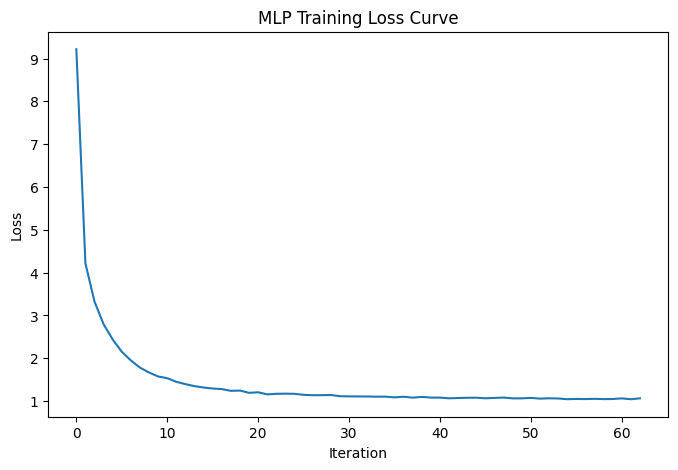

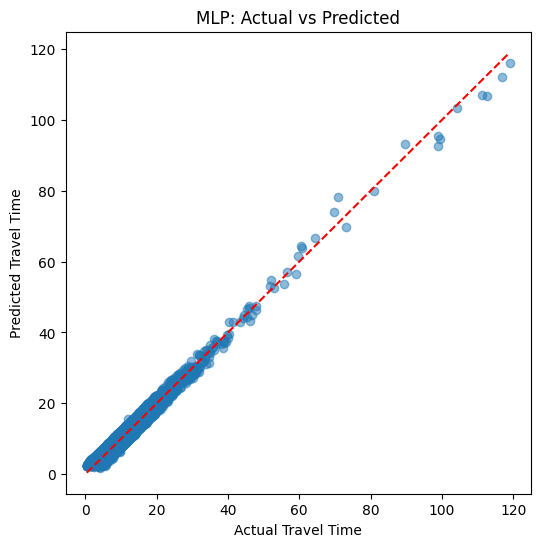

In [2]:
# plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.show()

# plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.5)
plt.xlabel("Actual Travel Time")
plt.ylabel("Predicted Travel Time")
plt.title("MLP: Actual vs Predicted")

# ideal line
min_val = min(y_test.min(), y_pred_mlp.min())
max_val = max(y_test.max(), y_pred_mlp.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()

X_test_original = X_test.copy()

## Optimization


PART A: Unconstrained Optimization
Optimization result for one traffic condition (unconstrained):
    Signal_Phase_Duration  Predicted_Travel_Time  Objective_Score
0                      30               8.423534         8.423534
1                      40               8.405814         8.405814
2                      50               8.382733         8.382733
3                      60               8.353736         8.353736
4                      70               8.324739         8.324739
5                      80               8.295742         8.295742
6                      90               8.266744         8.266744
7                     100               8.238906         8.238906
8                     110               8.228058         8.228058
9                     120               8.199281         8.199281
10                    130               8.165240         8.165240
11                    140               8.131199         8.131199
12                    150               8.1

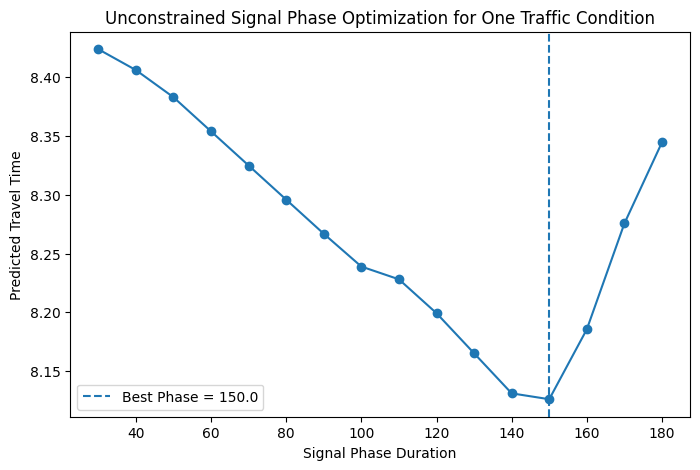


Unconstrained multi-sample summary:
   Best_Phase  Best_Predicted_Travel_Time
0       150.0                    8.126212
1       180.0                   17.411326
2       120.0                    8.423189
3       130.0                    9.301841
4       180.0                    8.442844

Average optimal phase (unconstrained): 108.4
Most common optimal phase (unconstrained): 180.0
Average minimum predicted travel time (unconstrained): 8.66673251608388


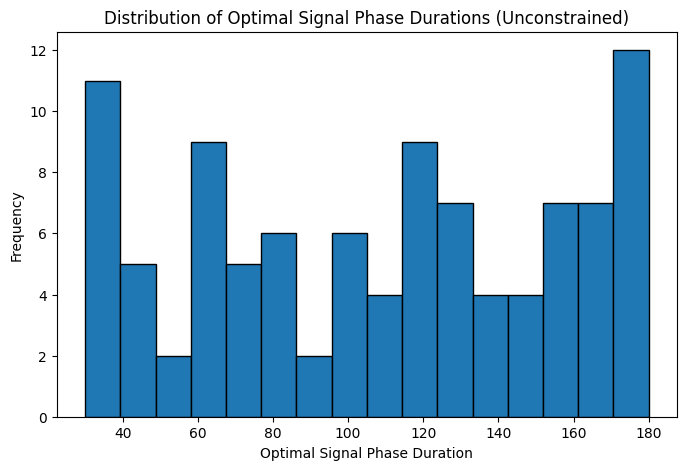

In [3]:
def optimize_signal_phase_for_sample(
    sample,
    model,
    scaler,
    features,
    phase_candidates,
    penalty_lambda=0.0
):
    results = []

    for phase in phase_candidates:
        temp_sample = sample.copy()
        temp_sample["Signal_Phase_Duration"] = phase

        temp_df = pd.DataFrame([temp_sample], columns=features)
        temp_scaled = scaler.transform(temp_df)

        pred_time = model.predict(temp_scaled)[0]
        objective_score = pred_time + penalty_lambda * phase

        results.append({
            "Signal_Phase_Duration": phase,
            "Predicted_Travel_Time": pred_time,
            "Objective_Score": objective_score
        })

    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df["Objective_Score"].idxmin()]

    return results_df, best_row

# unconstrained optimization
print("\n" + "="*70)
print("PART A: Unconstrained Optimization")
print("="*70)

sample_idx = 0
sample = X_test_original.iloc[sample_idx].copy()
phase_candidates_full = np.arange(30, 181, 10)

# no penalty
penalty_lambda_unconstrained = 0.0

results_unconstrained_df, best_unconstrained_row = optimize_signal_phase_for_sample(
    sample=sample,
    model=best_mlp,
    scaler=scaler,
    features=features,
    phase_candidates=phase_candidates_full,
    penalty_lambda=penalty_lambda_unconstrained
)

print("Optimization result for one traffic condition (unconstrained):")
print(results_unconstrained_df)
print("\nBest signal phase duration (unconstrained):", best_unconstrained_row["Signal_Phase_Duration"])
print("Minimum predicted travel time (unconstrained):", best_unconstrained_row["Predicted_Travel_Time"])

# plot unconstrained result
plt.figure(figsize=(8, 5))
plt.plot(
    results_unconstrained_df["Signal_Phase_Duration"],
    results_unconstrained_df["Predicted_Travel_Time"],
    marker="o"
)
plt.axvline(
    best_unconstrained_row["Signal_Phase_Duration"],
    linestyle="--",
    label=f"Best Phase = {best_unconstrained_row['Signal_Phase_Duration']}"
)
plt.xlabel("Signal Phase Duration")
plt.ylabel("Predicted Travel Time")
plt.title("Unconstrained Signal Phase Optimization for One Traffic Condition")
plt.legend()
plt.show()

# multi-sample unconstrained optimization
n_samples = min(100, len(X_test_original))
test_subset = X_test_original.iloc[:n_samples].copy()

all_best_phases_unconstrained = []
all_best_times_unconstrained = []

for i in range(len(test_subset)):
    base_sample = test_subset.iloc[i].copy()

    sample_results_df, best_row = optimize_signal_phase_for_sample(
        sample=base_sample,
        model=best_mlp,
        scaler=scaler,
        features=features,
        phase_candidates=phase_candidates_full,
        penalty_lambda=penalty_lambda_unconstrained
    )

    all_best_phases_unconstrained.append(best_row["Signal_Phase_Duration"])
    all_best_times_unconstrained.append(best_row["Predicted_Travel_Time"])

summary_unconstrained_df = pd.DataFrame({
    "Best_Phase": all_best_phases_unconstrained,
    "Best_Predicted_Travel_Time": all_best_times_unconstrained
})

print("\nUnconstrained multi-sample summary:")
print(summary_unconstrained_df.head())
print("\nAverage optimal phase (unconstrained):", summary_unconstrained_df["Best_Phase"].mean())
print("Most common optimal phase (unconstrained):", summary_unconstrained_df["Best_Phase"].mode()[0])
print("Average minimum predicted travel time (unconstrained):",
      summary_unconstrained_df["Best_Predicted_Travel_Time"].mean())

plt.figure(figsize=(8, 5))
plt.hist(
    summary_unconstrained_df["Best_Phase"],
    bins=len(phase_candidates_full),
    edgecolor="black"
)
plt.xlabel("Optimal Signal Phase Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Optimal Signal Phase Durations (Unconstrained)")
plt.show()


PART B: Improved Optimization with Penalty
Optimization result for one traffic condition (constrained):
   Signal_Phase_Duration  Predicted_Travel_Time  Objective_Score
0                     30               8.423534         8.438534
1                     40               8.405814         8.425814
2                     50               8.382733         8.407733
3                     60               8.353736         8.383736
4                     70               8.324739         8.359739
5                     80               8.295742         8.335742
6                     90               8.266744         8.311744
7                    100               8.238906         8.288906
8                    110               8.228058         8.283058
9                    120               8.199281         8.259281

Best signal phase duration (constrained): 120.0
Minimum predicted travel time (constrained): 8.199281039446317
Minimum objective score (constrained): 8.259281039446318


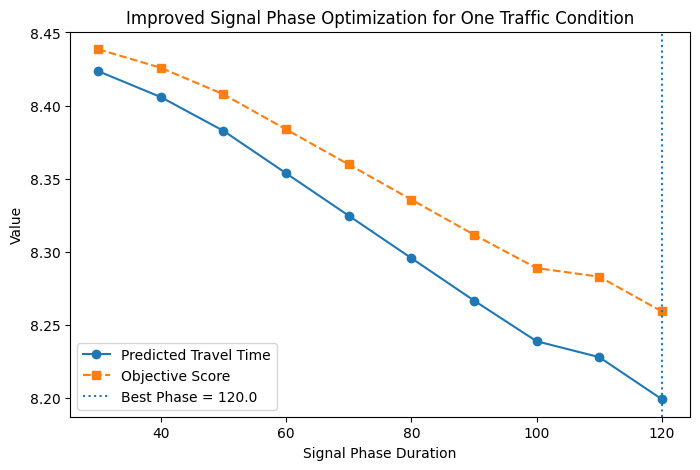


Constrained multi-sample summary:
   Best_Phase  Best_Predicted_Travel_Time  Best_Objective_Score
0       120.0                    8.199281              8.259281
1       120.0                   17.505513             17.565513
2       120.0                    8.423189              8.483189
3       120.0                    9.339653              9.399653
4       120.0                    8.642583              8.702583

Average optimal phase (constrained): 83.7
Most common optimal phase (constrained): 120.0
Average minimum predicted travel time (constrained): 8.710734325727465
Average minimum objective score (constrained): 8.752584325727467


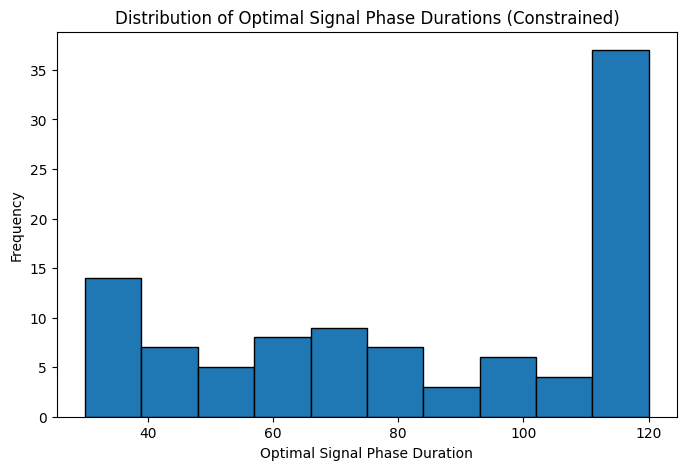

In [4]:
# constrained optimization with penalty
print("\n" + "="*70)
print("PART B: Improved Optimization with Penalty")
print("="*70)

phase_candidates_constrained = np.arange(30, 121, 10)
penalty_lambda_constrained = 0.0005

results_constrained_df, best_constrained_row = optimize_signal_phase_for_sample(
    sample=sample,
    model=best_mlp,
    scaler=scaler,
    features=features,
    phase_candidates=phase_candidates_constrained,
    penalty_lambda=penalty_lambda_constrained
)

print("Optimization result for one traffic condition (constrained):")
print(results_constrained_df)
print("\nBest signal phase duration (constrained):", best_constrained_row["Signal_Phase_Duration"])
print("Minimum predicted travel time (constrained):", best_constrained_row["Predicted_Travel_Time"])
print("Minimum objective score (constrained):", best_constrained_row["Objective_Score"])

# plot constrained result
plt.figure(figsize=(8, 5))
plt.plot(
    results_constrained_df["Signal_Phase_Duration"],
    results_constrained_df["Predicted_Travel_Time"],
    marker="o",
    label="Predicted Travel Time"
)
plt.plot(
    results_constrained_df["Signal_Phase_Duration"],
    results_constrained_df["Objective_Score"],
    marker="s",
    linestyle="--",
    label="Objective Score"
)
plt.axvline(
    best_constrained_row["Signal_Phase_Duration"],
    linestyle=":",
    label=f"Best Phase = {best_constrained_row['Signal_Phase_Duration']}"
)
plt.xlabel("Signal Phase Duration")
plt.ylabel("Value")
plt.title("Improved Signal Phase Optimization for One Traffic Condition")
plt.legend()
plt.show()

# multi-sample constrained optimization
all_best_phases_constrained = []
all_best_times_constrained = []
all_best_scores_constrained = []

for i in range(len(test_subset)):
    base_sample = test_subset.iloc[i].copy()

    sample_results_df, best_row = optimize_signal_phase_for_sample(
        sample=base_sample,
        model=best_mlp,
        scaler=scaler,
        features=features,
        phase_candidates=phase_candidates_constrained,
        penalty_lambda=penalty_lambda_constrained
    )

    all_best_phases_constrained.append(best_row["Signal_Phase_Duration"])
    all_best_times_constrained.append(best_row["Predicted_Travel_Time"])
    all_best_scores_constrained.append(best_row["Objective_Score"])

summary_constrained_df = pd.DataFrame({
    "Best_Phase": all_best_phases_constrained,
    "Best_Predicted_Travel_Time": all_best_times_constrained,
    "Best_Objective_Score": all_best_scores_constrained
})

print("\nConstrained multi-sample summary:")
print(summary_constrained_df.head())

print("\nAverage optimal phase (constrained):", summary_constrained_df["Best_Phase"].mean())
print("Most common optimal phase (constrained):", summary_constrained_df["Best_Phase"].mode()[0])
print("Average minimum predicted travel time (constrained):",
      summary_constrained_df["Best_Predicted_Travel_Time"].mean())
print("Average minimum objective score (constrained):",
      summary_constrained_df["Best_Objective_Score"].mean())

plt.figure(figsize=(8, 5))
plt.hist(
    summary_constrained_df["Best_Phase"],
    bins=len(phase_candidates_constrained),
    edgecolor="black"
)
plt.xlabel("Optimal Signal Phase Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Optimal Signal Phase Durations (Constrained)")
plt.show()

In [5]:
# comparison
print("\n" + "="*70)
print("PART C: Comparison")
print("="*70)

comparison_df = pd.DataFrame({
    "Setting": ["Unconstrained", "Constrained"],
    "Average_Optimal_Phase": [
        summary_unconstrained_df["Best_Phase"].mean(),
        summary_constrained_df["Best_Phase"].mean()
    ],
    "Most_Common_Optimal_Phase": [
        summary_unconstrained_df["Best_Phase"].mode()[0],
        summary_constrained_df["Best_Phase"].mode()[0]
    ],
    "Average_Minimum_Predicted_Travel_Time": [
        summary_unconstrained_df["Best_Predicted_Travel_Time"].mean(),
        summary_constrained_df["Best_Predicted_Travel_Time"].mean()
    ]
})

print(comparison_df)

# sensitivity analysis for lambda
print("\n" + "="*70)
print("PART D: Sensitivity Analysis")
print("="*70)

lambda_results = []

for lam in [0.0, 0.0005, 0.001, 0.005, 0.01]:
    _, best_row = optimize_signal_phase_for_sample(
        sample=sample,
        model=best_mlp,
        scaler=scaler,
        features=features,
        phase_candidates=phase_candidates_constrained,
        penalty_lambda=lam
    )

    lambda_results.append({
        "lambda": lam,
        "best_phase": best_row["Signal_Phase_Duration"],
        "best_predicted_time": best_row["Predicted_Travel_Time"],
        "best_objective_score": best_row["Objective_Score"]
    })

lambda_df = pd.DataFrame(lambda_results)

print(lambda_df)


PART C: Comparison
         Setting  Average_Optimal_Phase  Most_Common_Optimal_Phase  \
0  Unconstrained                  108.4                      180.0   
1    Constrained                   83.7                      120.0   

   Average_Minimum_Predicted_Travel_Time  
0                               8.666733  
1                               8.710734  

PART D: Sensitivity Analysis
   lambda  best_phase  best_predicted_time  best_objective_score
0  0.0000       120.0             8.199281              8.199281
1  0.0005       120.0             8.199281              8.259281
2  0.0010       120.0             8.199281              8.319281
3  0.0050        30.0             8.423534              8.573534
4  0.0100        30.0             8.423534              8.723534
